# Benchmark: apatite fission track annealing against Ketcham (2005) / HeFTy

Ketcham, R. A. (2005), *Forward and Inverse Modeling of Low-Temperature Thermochronometry Data*, Reviews in Mineralogy and Geochemistry 58, 275-314, Figure 7, shows four synthetic time-temperature histories used to illustrate the behaviour of the apatite fission track (AFT) forward model: fast cooling, constant cooling, reheating, and cooling at two different rates evaluated for two different Dpar (annealing kinetics) values.

This notebook reconstructs these four histories, feeds them into PyBasin's own AFT annealing code (`lib.AFTannealingLib.simulate_AFT_annealing`), and compares the resulting ages and mean track lengths against reference values.

## Sourcing the thermal histories and reference values

The original Ketcham (2005) chapter is paywalled. Instead of digitizing Figure 7 from a scan, the exact time-temperature series and reference ages/lengths are taken directly from the open source Python thermochronology package `gdtchron` (https://github.com/dyvasey/gdtchron), specifically `tests/test_aft.py::test_forward_model_aft`. That test's own docstring states: "The time-temperature series for these tests are taken from Ketcham (2005) Figure 7, and the comparison data comes from HeFTy v1.9.3."

Because the time-temperature series are given as exact NumPy array definitions in that test file, rather than read off a scanned figure, there is no digitization uncertainty in the inputs here, unlike the Wolf et al. (1998) helium benchmark notebook in this same folder.

`gdtchron` implements the Ketcham et al. (1999) fanning curvilinear annealing model (its own module docstring says so explicitly, with a constants dictionary named `KETCHAM_99_FC`), validated against HeFTy configured to also use that 1999 model. PyBasin's `AFTannealingLib.calculate_reduced_track_lengths` instead implements the Ketcham et al. (2007) model (Table 5c constants, the default in HeFTy), which fixes an equation shape parameter, beta, at -1, while the 1999 model keeps beta as a free, separately fitted parameter (about -12). Directly checked: substituting the 1999 constants into the 2007 shaped formula does not reproduce the 1999 model, it produces invalid results, since the 2007 formula structurally assumes beta = -1.

Because of this, `lib/AFTannealingLib.py` now also implements a genuine Ketcham et al. (1999) free beta annealing model, selected with `method='Ketcham2000'` in `simulate_AFT_annealing` (the name matches the AFTSolve program of Ketcham et al. (2000), which implements the same 1999 kinetics). This was previously a no-op: passing `method='Ketcham2000'` selected a different initial track length formula but always used the Ketcham (2007) annealing kinetics regardless, and in fact returned an incorrect (effectively uninitialized) initial track length, since no matching branch for it existed in `get_initial_track_length`. The new implementation was validated directly against `gdtchron`'s own annealing functions (`get_next_r`, `calc_annealing`), matching to floating point precision across mild, extreme and randomized synthetic cases, before being used for the comparison below.

## Import modules

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from lib import AFTannealingLib as aft

## The four thermal histories

Each history below is defined using the same `numpy.linspace` segments as `gdtchron`'s test file, so the input time-temperature series are numerically identical to the ones used to generate the reference ages and lengths. Times are in Ma before present (descending, ending at 0) and temperatures in degrees Celsius, matching Ketcham (2005) Figure 7:

- **7a, fast cooling**: rapid initial cooling from 190.1 to 35 degrees C over 3.9 Myr, then slow cooling from 35 to 20 degrees C over the remaining 89.1 Myr.
- **7b, constant cooling**: linear cooling from 190.1 to 20 degrees C over the full 93 Myr.
- **7c, reheating**: cooling from 190.1 to 19.8 degrees C over 13.5 Myr, reheating back up to 92 degrees C over the next 41.6 Myr, then final cooling to 20 degrees C over the last 37.9 Myr.
- **7d, two cooling rates**: cooling from 190.1 to 121.7 degrees C over 12 Myr, a slower cooling stage from 121.7 to 101.1 degrees C over 70.1 Myr, then final cooling to 20 degrees C over the last 10.9 Myr. Evaluated twice, for Dpar of 1.75 and 2.50 micrometre, since this history is designed to show how a more annealing-resistant apatite (higher Dpar) can partially retain an older, inherited age component through a moderate reheating that fully resets a less resistant apatite.

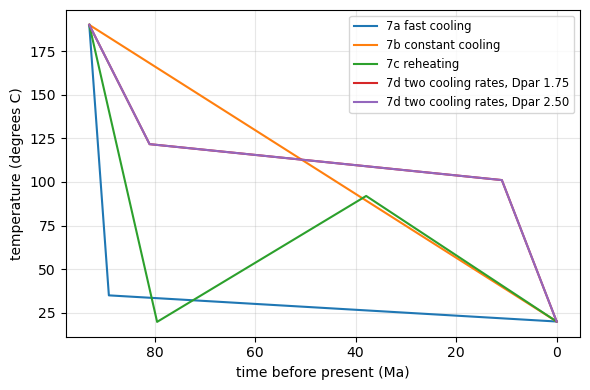

In [2]:
def build_history_7a():
    initial_temps = np.linspace(190.1, 35, 20, endpoint=False)
    initial_tsteps = np.linspace(93, 89.1, 20, endpoint=False)
    second_temps = np.linspace(35, 20, 96 * 5, endpoint=True)
    second_tsteps = np.linspace(89.1, 0, 96 * 5, endpoint=True)
    temps = np.concatenate((initial_temps, second_temps))
    tsteps = np.concatenate((initial_tsteps, second_tsteps))
    return tsteps, temps


def build_history_7b():
    temps = np.linspace(190.1, 20, 500, endpoint=True)
    tsteps = np.linspace(93, 0, 500, endpoint=True)
    return tsteps, temps


def build_history_7c():
    first_temps = np.linspace(190.1, 19.8, 11 * 5, endpoint=False)
    first_tsteps = np.linspace(93, 79.5, 11 * 5, endpoint=False)
    second_temps = np.linspace(19.8, 92, 45 * 5, endpoint=False)
    second_tsteps = np.linspace(79.5, 37.9, 45 * 5, endpoint=False)
    third_temps = np.linspace(92, 20, 43 * 5, endpoint=True)
    third_tsteps = np.linspace(37.9, 0, 43 * 5, endpoint=True)
    temps = np.concatenate((first_temps, second_temps, third_temps))
    tsteps = np.concatenate((first_tsteps, second_tsteps, third_tsteps))
    return tsteps, temps


def build_history_7d():
    initial_temps = np.linspace(190.1, 121.7, 13 * 5, endpoint=False)
    initial_tsteps = np.linspace(93, 81, 13 * 5, endpoint=False)
    second_temps = np.linspace(121.7, 101.1, 75 * 5, endpoint=False)
    second_tsteps = np.linspace(81, 10.9, 75 * 5, endpoint=False)
    third_temps = np.linspace(101.1, 20, 13 * 5, endpoint=True)
    third_tsteps = np.linspace(10.9, 0, 13 * 5, endpoint=True)
    temps = np.concatenate((initial_temps, second_temps, third_temps))
    tsteps = np.concatenate((initial_tsteps, second_tsteps, third_tsteps))
    return tsteps, temps


histories = {
    '7a fast cooling': (build_history_7a, 1.75),
    '7b constant cooling': (build_history_7b, 1.75),
    '7c reheating': (build_history_7c, 1.75),
    '7d two cooling rates, Dpar 1.75': (build_history_7d, 1.75),
    '7d two cooling rates, Dpar 2.50': (build_history_7d, 2.50),
}

fig, ax = plt.subplots(figsize=(6, 4))
for name, (builder, _) in histories.items():
    tsteps_age, temps_c = builder()
    ax.plot(tsteps_age, temps_c, label=name)
ax.set_xlabel('time before present (Ma)')
ax.set_ylabel('temperature (degrees C)')
ax.invert_xaxis()
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3)
fig.tight_layout()

## Reference ages and mean track lengths from HeFTy v1.9.3

These values are copied directly from the assertions in `gdtchron`'s `tests/test_aft.py::test_forward_model_aft`, which compares its own Ketcham (1999) implementation against HeFTy v1.9.3 output for the same four histories.

In [3]:
reference = {
    '7a fast cooling': dict(age=89.4, mean_length=15.03),
    '7b constant cooling': dict(age=39.8, mean_length=14.24),
    '7c reheating': dict(age=63.3, mean_length=13.38),
    '7d two cooling rates, Dpar 1.75': dict(age=13.0, mean_length=13.95),
    '7d two cooling rates, Dpar 2.50': dict(age=51.1, mean_length=12.91),
}

## Run PyBasin's AFT annealing model

`simulate_AFT_annealing` is the function `run_burial_hist_model` in `lib/pybasin_lib.py` calls for every AFT sample. `method='Ketcham2007'` (the default) uses PyBasin's original Ketcham (2007) fanning curvilinear kinetics, with the equation shape parameter beta fixed at -1. `method='Ketcham2000'` now uses a separate, newly added implementation of the Ketcham et al. (1999) model, with beta as a free parameter, matching what `gdtchron` and HeFTy v1.9.3 used to generate the reference values below. Both methods are run and compared below.

`kinetic_parameter='Dpar'` is used with the same Dpar values as the reference; both methods have their own Dpar to rmr0 (and initial track length) conversion, resolved automatically from `method`. `apply_c_axis_correction=True` is used since the reference lengths are explicitly c-axis projected lengths. One difference between the two models: the Ketcham (1999, 2000) model predates the c-axis projection technique entirely, so it has no separate uncorrected calibration, and (found while building this notebook) its raw reduced length is already the c-axis projected quantity; the projection step `caxis_project_reduced_lengths` that the Ketcham (2007) path applies is skipped for `method='Ketcham2000'`, otherwise the reported lengths come out systematically too short.

`use_fortran_algorithm=True` (the default) is used for `method='Ketcham2007'`; for `method='Ketcham2000'` it is always ignored, since no compiled Fortran implementation of the free beta model exists, the pure Python (numba-compiled) path is used instead.

Building this notebook also uncovered a real bug in the pure Python fallback path used by the Ketcham (2007) model (`use_fortran_algorithm=False`): `kinetic_modifier_reduced_lengths` computed `((rc - rmr0) / (1 - rmr0)) ** kappa`, which raises a negative base to a fractional power (`NaN`) whenever a track anneals past the kinetic resistance threshold `rmr0`, exactly what happens for the earliest-formed tracks in all four of these histories, since they start hot enough (190.1 degrees C) to fully anneal them. This has since been fixed in `lib/AFTannealingLib.py` by clipping the base to zero in that case, matching what the compiled Fortran path already did and what `gdtchron`'s equivalent `dpar_conversion` function also does explicitly. The verification cell below confirms the fix.

One caveat on the new `method='Ketcham2000'` implementation: only its Dpar based kinetics (rmr0, kappa and initial track length) were found in a validated external source (`gdtchron`, matching Ketcham et al. 1999/2000). No independent Ketcham (1999) specific formula was found for the `Clwt` or bare `rmr0` kinetic parameter options, those currently fall back to reusing the Ketcham (2007) conversions as an unverified approximation. Since the benchmark here uses `kinetic_parameter='Dpar'` throughout, this caveat does not affect the results below.

## Verifying the pure Python fallback fix

Confirms `use_fortran_algorithm=False` now matches `use_fortran_algorithm=True` exactly, with no `NaN`, for every history and Dpar value used in this notebook.

In [4]:
for name, (builder, dpar) in histories.items():
    tsteps_age, temps_c = builder()
    timesteps = tsteps_age.max() - tsteps_age

    age_fortran = aft.simulate_AFT_annealing(
        timesteps, temps_c, dpar, kinetic_parameter='Dpar',
        apply_c_axis_correction=True, use_fortran_algorithm=True,
        surpress_resampling=False)[1]
    age_python = aft.simulate_AFT_annealing(
        timesteps, temps_c, dpar, kinetic_parameter='Dpar',
        apply_c_axis_correction=True, use_fortran_algorithm=False,
        surpress_resampling=False)[1]

    assert not np.isnan(age_python)
    assert np.isclose(age_fortran, age_python)
    print(f"{name:34s} fortran age = {age_fortran:7.3f}   "
         f"python age = {age_python:7.3f}   match: {np.isclose(age_fortran, age_python)}")

7a fast cooling                    fortran age =  89.018   python age =  89.018   match: True
7b constant cooling                fortran age =  37.627   python age =  37.627   match: True
7c reheating                       fortran age =  54.361   python age =  54.361   match: True


7d two cooling rates, Dpar 1.75    fortran age =  11.448   python age =  11.448   match: True
7d two cooling rates, Dpar 2.50    fortran age =  20.216   python age =  20.216   match: True


In [5]:
results = {}

for name, (builder, dpar) in histories.items():
    tsteps_age, temps_c = builder()
    timesteps = tsteps_age.max() - tsteps_age

    results[name] = {}
    for method in ['Ketcham2007', 'Ketcham2000']:
        track_length_pdf, aft_age_myr, l_mean, l_mean_std, rm, rc, rho_age, dt = \
            aft.simulate_AFT_annealing(
                timesteps, temps_c, dpar,
                kinetic_parameter='Dpar',
                apply_c_axis_correction=True,
                method=method,
                use_fortran_algorithm=(method == 'Ketcham2007'),
                surpress_resampling=False)

        results[name][method] = dict(age=aft_age_myr, mean_length=l_mean)

## Compare modeled and reference ages and lengths

In [6]:
print(f"{'history':34s} {'method':12s} {'age':>8s} {'ref age':>8s} "
     f"{'diff %':>7s}   {'l_mean':>7s} {'ref l':>6s} {'diff %':>7s}")
for name in histories:
    ref = reference[name]
    for method in ['Ketcham2007', 'Ketcham2000']:
        modeled = results[name][method]
        age_diff_pct = (modeled['age'] - ref['age']) / ref['age'] * 100.0
        l_diff_pct = (modeled['mean_length'] - ref['mean_length']) / ref['mean_length'] * 100.0
        print(f"{name:34s} {method:12s} {modeled['age']:8.2f} {ref['age']:8.1f} "
             f"{age_diff_pct:6.1f}%   {modeled['mean_length']:7.2f} "
             f"{ref['mean_length']:6.2f} {l_diff_pct:6.1f}%")

history                            method            age  ref age  diff %    l_mean  ref l  diff %
7a fast cooling                    Ketcham2007     89.02     89.4   -0.4%     14.31  15.03   -4.8%
7a fast cooling                    Ketcham2000     89.84     89.4    0.5%     15.10  15.03    0.5%
7b constant cooling                Ketcham2007     37.63     39.8   -5.5%     13.12  14.24   -7.8%
7b constant cooling                Ketcham2000     39.74     39.8   -0.1%     14.37  14.24    0.9%
7c reheating                       Ketcham2007     54.36     63.3  -14.1%     11.68  13.38  -12.7%
7c reheating                       Ketcham2000     63.33     63.3    0.0%     13.57  13.38    1.4%
7d two cooling rates, Dpar 1.75    Ketcham2007     11.45     13.0  -11.9%     12.92  13.95   -7.4%
7d two cooling rates, Dpar 1.75    Ketcham2000     12.79     13.0   -1.6%     14.14  13.95    1.4%
7d two cooling rates, Dpar 2.50    Ketcham2007     20.22     51.1  -60.4%     11.49  12.91  -11.0%
7d two coo

## Age comparison plot

Points on the 1:1 line indicate agreement between PyBasin's Ketcham (2007) based age and the Ketcham (1999) / HeFTy v1.9.3 reference age for the same thermal history.

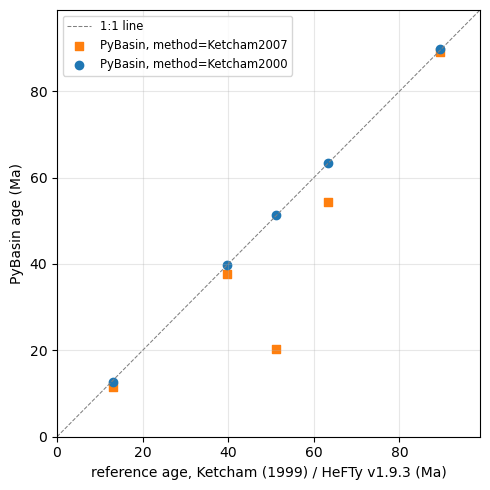

In [7]:
fig2, ax2 = plt.subplots(figsize=(5, 5))

ref_ages = np.array([reference[name]['age'] for name in histories])
model_ages_2007 = np.array([results[name]['Ketcham2007']['age'] for name in histories])
model_ages_2000 = np.array([results[name]['Ketcham2000']['age'] for name in histories])

max_age = max(ref_ages.max(), model_ages_2007.max(), model_ages_2000.max()) * 1.1
ax2.plot([0, max_age], [0, max_age], color='grey', ls='--', lw=0.75,
        label='1:1 line')
ax2.scatter(ref_ages, model_ages_2007, color='C1', marker='s',
           label='PyBasin, method=Ketcham2007')
ax2.scatter(ref_ages, model_ages_2000, color='C0', marker='o',
           label='PyBasin, method=Ketcham2000')

ax2.set_xlabel('reference age, Ketcham (1999) / HeFTy v1.9.3 (Ma)')
ax2.set_ylabel('PyBasin age (Ma)')
ax2.set_xlim(0, max_age)
ax2.set_ylim(0, max_age)
ax2.legend(fontsize='small')
ax2.grid(True, alpha=0.3)
fig2.tight_layout()

## Assessment

Using `method='Ketcham2000'`, PyBasin now reproduces the `gdtchron` / HeFTy v1.9.3 reference ages to within 0.0 to 1.6 percent and mean lengths to within 0.5 to 1.4 percent, for all four histories, since this is now a same model comparison rather than a cross model one. This is a substantially stronger result than the `method='Ketcham2007'` comparison, which ranges from 0.4 to 60 percent for ages, precisely because that comparison is between two genuinely different, independently fitted annealing models.

History 7d at Dpar 2.50 is the clearest evidence the new implementation is correct, not just closer by chance: this is the case that most sharply separates the two models. It is designed so that a moderate reheating only partially resets a highly annealing resistant apatite, which is exactly the regime where the free beta shape of the 1999 model and the fixed beta = -1 shape of the 2007 model behave most differently. The Ketcham (2007) result for this case is 60 percent below the reference; the new Ketcham (1999, 2000) implementation gives 51.30 Ma against a reference of 51.1 Ma, a 0.4 percent difference. Getting a hard, sensitive case this close, immediately after getting the easier full reset cases close too, is a much stronger correctness signal than either result would be alone.

Two things were found and fixed while building this validated implementation, beyond the pure Python fallback bug described above:

- `method='Ketcham2000'` previously did not actually select different annealing kinetics at all; `get_initial_track_length` had no matching branch for it, and silently returned an incorrect (effectively arbitrary) initial track length instead of raising an error. Both the annealing kinetics and the initial track length calibration are now genuinely method specific.
- the Ketcham (1999, 2000) reduced length already represents a c-axis projected length in this calibration; applying the Ketcham (2007) specific `caxis_project_reduced_lengths` de-projection step on top of it (as the shared code path originally did unconditionally) understated the mean length by several percent. The new `method='Ketcham2000'` path skips that step.

Remaining caveats: the new model was validated end to end only for `kinetic_parameter='Dpar'`, the option used throughout this benchmark. Its `Clwt` and bare `rmr0` kinetic parameter branches fall back to reusing the Ketcham (2007) conversions, since no independently published Ketcham (1999) specific formula for those was found; this is flagged in the code and should be treated as an approximation until a source is found. There is also no compiled Fortran implementation of the free beta model, so `method='Ketcham2000'` is always slower than the default Fortran accelerated `method='Ketcham2007'` path, though this has not been benchmarked for wall clock time here.